In [6]:

class Value:
    def __init__(self, data, _children=(), _op="", label=""):
        self.data = data
        self.grad = 0.0
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), "+")
        return out

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), "*")
        return out

In [7]:
from graphviz import Digraph


def trace(root):
    nodes, edges = set(), set()

    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)

    build(root)
    return nodes, edges


def draw_dot(root):
    dot = Digraph(format="svg", graph_attr={"rankdir": "LR"})
    nodes, edges = trace(root)

    for n in nodes:
        uid = str(id(n))
        # Value node
        dot.node(
            name=uid,
            label=f"{{ {n.label} | data {n.data:.4f} | grad {n.grad:.4f} }}",
            shape="record",
        )
        # Operation node (if any)
        if n._op:
            op_id = uid + n._op
            dot.node(name=op_id, label=n._op)
            dot.edge(op_id, uid)

    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

In [46]:
a = Value(5, label="a")
b = Value(-3, label="b")
c = Value(10, label="c")
e = a*b; e.label = "e"
d = c + e; d.label = "d"
f = Value(10, label="f")
L = d*f; L.label = "L"
L.grad = 1.0
d.grad = f.data
f.grad = d.data
c.grad = f.data
e.grad = f.data
a.grad = b.data * e.grad
b.grad = a.data * e.grad
L

Value(data=-50)

In [ ]:
L = (c+a*b)*f

dl/da = 

SyntaxError: cannot assign to expression (2975476268.py, line 3)

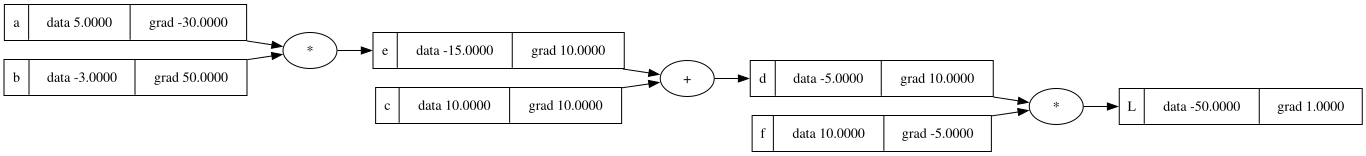

In [47]:
draw_dot(L)

In [48]:
def lol():
    h = 0.0001
    a = Value(5, label="a")
    b = Value(-3, label="b")
    c = Value(10, label="c")
    e = a*b; e.label = "e"
    d = c + e; d.label = "d"
    f = Value(10, label="f")
    L1 = d*f; L1.label = "L"
    
    a = Value(5, label="a")
    b = Value(-3, label="b")
    b.data += h
    c = Value(10, label="c")
    e = a*b; e.label = "e"
    d = c + e; d.label = "d"
    f = Value(10, label="f")
    L2 = d*f; L2.label = "L"   

    return (L2.data-L1.data)/h

lol()

50.000000000096634

9.999999999976694

In [ ]:
|